<a href="https://colab.research.google.com/github/Nandhini0226/British-Airways---Customer-Segmentation-Revenue-Optimization-with-Machine-Learning-/blob/main/(EV)_Adoption_Likelihood_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [85]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline


In [86]:
# Import Logistic Regression and evaluation metrics
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [87]:
url = "https://raw.githubusercontent.com/Nandhini0226/EV-Adoption-Likelihood-Prediction-Classification/main/global_ev_adoption_behavior_2026.csv"

df = pd.read_csv(url)

In [88]:
df

,age,annual_income,education_level,city_type,daily_commute_km,weekly_travel_distance_km,current_vehicle_type,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,...,environmental_awareness_score,government_incentive_awareness,technology_affinity_score,range_anxiety_score,battery_replacement_concern,ev_knowledge_score,previous_ev_experience,ev_adoption_likelihood,monthly_energy_consumption_kwh,monthly_charging_cost
0,56,23019.0,High School,Suburban,39.8,205.7,Hatchback,6.1,317.1,3.9,...,8.3,6.4,5.2,4.6,3.5,6.9,0,High,199.8,28.5
1,46,26440.0,High School,Suburban,34.6,218.4,Sedan,4.4,290.0,4.5,...,7.8,10.0,5.7,5.5,7.4,6.9,1,High,139.8,22.9
2,46,57167.0,PhD,Suburban,30.5,177.7,Sedan,0.4,201.4,6.3,...,7.6,6.4,7.8,5.3,6.2,6.8,0,High,158.0,38.5
3,23,15841.0,Master,Suburban,44.6,325.9,SUV,0.0,407.3,5.2,...,6.2,5.6,5.1,7.9,5.7,7.2,0,Low,207.0,45.0
4,50,51571.0,Master,Urban,52.4,281.0,SUV,5.2,458.4,4.3,...,9.7,9.9,8.2,2.6,4.7,8.1,0,High,195.6,43.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,27,26296.0,Bachelor,Urban,37.4,211.4,Sedan,0.0,314.8,10.0,...,9.9,6.6,8.9,5.1,7.8,9.3,1,High,162.5,37.5
49996,39,35476.0,Master,Suburban,30.5,158.3,Sedan,2.8,278.5,7.5,...,8.7,6.0,9.4,3.8,2.0,8.8,0,High,129.6,11.9
49997,30,20862.0,Master,Suburban,37.5,295.2,Sedan,0.0,358.4,7.7,...,7.3,6.6,4.5,5.2,1.3,5.9,0,High,218.3,52.8
49998,68,14694.0,Bachelor,Rural,40.3,256.5,Sedan,6.0,306.1,2.7,...,8.3,3.8,6.6,4.7,5.4,9.3,0,High,216.0,50.3


# **Initial Data Inspection**

In [89]:
# Dataset Shape
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(50000, 23)


In [90]:
# Column Names
print("\nColumn Names:")
print(df.columns.tolist())


Column Names:
['age', 'annual_income', 'education_level', 'city_type', 'daily_commute_km', 'weekly_travel_distance_km', 'current_vehicle_type', 'vehicle_age_years', 'fuel_expense_per_month', 'charging_station_accessibility', 'nearest_charging_station_km', 'home_charging_available', 'electricity_cost_per_kwh', 'environmental_awareness_score', 'government_incentive_awareness', 'technology_affinity_score', 'range_anxiety_score', 'battery_replacement_concern', 'ev_knowledge_score', 'previous_ev_experience', 'ev_adoption_likelihood', 'monthly_energy_consumption_kwh', 'monthly_charging_cost']


**Dataset Attributes Explanation**

| Attribute Name                     | Data Type                     | Description                                                                                                         |
| ---------------------------------- | ----------------------------- | ------------------------------------------------------------------------------------------------------------------- |
| **age**                            | Numerical                     | Age of the individual in years.                                                                                     |
| **annual_income**                  | Numerical                     | Annual income of the individual, typically measured in currency units.                                              |
| **education_level**                | Categorical                   | Highest level of education attained (e.g., High School, Bachelor, Master, PhD).                                     |
| **city_type**                      | Categorical                   | Type of residential area (Urban, Suburban, Rural).                                                                  |
| **daily_commute_km**               | Numerical                     | Average distance traveled daily for commuting, measured in kilometers.                                              |
| **weekly_travel_distance_km**      | Numerical                     | Total distance traveled per week, measured in kilometers.                                                           |
| **current_vehicle_type**           | Categorical                   | Type of vehicle currently owned or used (e.g., Sedan, SUV, Hatchback).                                              |
| **vehicle_age_years**              | Numerical                     | Age of the current vehicle in years.                                                                                |
| **fuel_expense_per_month**         | Numerical                     | Average monthly expenditure on fuel.                                                                                |
| **charging_station_accessibility** | Numerical                     | Accessibility score indicating ease of access to EV charging stations. Higher values indicate better accessibility. |
| **nearest_charging_station_km**    | Numerical                     | Distance to the nearest EV charging station in kilometers.                                                          |
| **home_charging_available**        | Binary (0/1)                  | Indicates whether home charging facilities are available (1 = Yes, 0 = No).                                         |
| **electricity_cost_per_kwh**       | Numerical                     | Cost of electricity per kilowatt-hour (kWh).                                                                        |
| **environmental_awareness_score**  | Numerical                     | Score representing awareness and concern for environmental sustainability.                                          |
| **government_incentive_awareness** | Numerical                     | Awareness score regarding government incentives and subsidies for EV adoption.                                      |
| **technology_affinity_score**      | Numerical                     | Score measuring interest in and willingness to adopt new technologies.                                              |
| **range_anxiety_score**            | Numerical                     | Score indicating concern about EV driving range limitations. Higher scores indicate greater anxiety.                |
| **battery_replacement_concern**    | Numerical                     | Score measuring concern about EV battery replacement costs and lifespan.                                            |
| **ev_knowledge_score**             | Numerical                     | Score representing knowledge and understanding of electric vehicles.                                                |
| **previous_ev_experience**         | Binary (0/1)                  | Indicates whether the individual has previously used or owned an EV (1 = Yes, 0 = No).                              |
| **ev_adoption_likelihood**         | Target Variable (Categorical) | Likelihood of adopting an Electric Vehicle (High, Medium, Low).                                                     |
| **monthly_energy_consumption_kwh** | Numerical                     | Estimated monthly energy consumption in kilowatt-hours.                                                             |
| **monthly_charging_cost**          | Numerical                     | Estimated monthly cost of charging an electric vehicle.                                                             |


In [91]:
# First 5 Records
print("\nFirst 5 Rows:")
display(df.head())


First 5 Rows:


,age,annual_income,education_level,city_type,daily_commute_km,weekly_travel_distance_km,current_vehicle_type,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,...,environmental_awareness_score,government_incentive_awareness,technology_affinity_score,range_anxiety_score,battery_replacement_concern,ev_knowledge_score,previous_ev_experience,ev_adoption_likelihood,monthly_energy_consumption_kwh,monthly_charging_cost
0,56,23019.0,High School,Suburban,39.8,205.7,Hatchback,6.1,317.1,3.9,...,8.3,6.4,5.2,4.6,3.5,6.9,0,High,199.8,28.5
1,46,26440.0,High School,Suburban,34.6,218.4,Sedan,4.4,290.0,4.5,...,7.8,10.0,5.7,5.5,7.4,6.9,1,High,139.8,22.9
2,46,57167.0,PhD,Suburban,30.5,177.7,Sedan,0.4,201.4,6.3,...,7.6,6.4,7.8,5.3,6.2,6.8,0,High,158.0,38.5
3,23,15841.0,Master,Suburban,44.6,325.9,SUV,0.0,407.3,5.2,...,6.2,5.6,5.1,7.9,5.7,7.2,0,Low,207.0,45.0
4,50,51571.0,Master,Urban,52.4,281.0,SUV,5.2,458.4,4.3,...,9.7,9.9,8.2,2.6,4.7,8.1,0,High,195.6,43.9


In [92]:
# Dataset Information
print("\nDataset Information:")
df.info()



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             50000 non-null  int64  
 1   annual_income                   50000 non-null  float64
 2   education_level                 49500 non-null  object 
 3   city_type                       50000 non-null  object 
 4   daily_commute_km                50000 non-null  float64
 5   weekly_travel_distance_km       50000 non-null  float64
 6   current_vehicle_type            50000 non-null  object 
 7   vehicle_age_years               50000 non-null  float64
 8   fuel_expense_per_month          50000 non-null  float64
 9   charging_station_accessibility  49500 non-null  float64
 10  nearest_charging_station_km     50000 non-null  float64
 11  home_charging_available         50000 non-null  int64  
 12  electricit

In [93]:
# Data Types
print("\nData Types:")
print(df.dtypes)



Data Types:
age                                 int64
annual_income                     float64
education_level                    object
city_type                          object
daily_commute_km                  float64
weekly_travel_distance_km         float64
current_vehicle_type               object
vehicle_age_years                 float64
fuel_expense_per_month            float64
charging_station_accessibility    float64
nearest_charging_station_km       float64
home_charging_available             int64
electricity_cost_per_kwh          float64
environmental_awareness_score     float64
government_incentive_awareness    float64
technology_affinity_score         float64
range_anxiety_score               float64
battery_replacement_concern       float64
ev_knowledge_score                float64
previous_ev_experience              int64
ev_adoption_likelihood             object
monthly_energy_consumption_kwh    float64
monthly_charging_cost             float64
dtype: object


In [94]:
# Duplicate Records
print("\nDuplicate Rows:")
print(df.duplicated().sum())


Duplicate Rows:
0


In [95]:
# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
age                                 0
annual_income                       0
education_level                   500
city_type                           0
daily_commute_km                    0
weekly_travel_distance_km           0
current_vehicle_type                0
vehicle_age_years                   0
fuel_expense_per_month              0
charging_station_accessibility    500
nearest_charging_station_km         0
home_charging_available             0
electricity_cost_per_kwh            0
environmental_awareness_score       0
government_incentive_awareness      0
technology_affinity_score           0
range_anxiety_score                 0
battery_replacement_concern         0
ev_knowledge_score                500
previous_ev_experience              0
ev_adoption_likelihood              0
monthly_energy_consumption_kwh      0
monthly_charging_cost               0
dtype: int64


In [96]:
# Statistical Summary Including Categorical Columns
print("\nComplete Summary:")
display(df.describe(include='all'))


Complete Summary:


,age,annual_income,education_level,city_type,daily_commute_km,weekly_travel_distance_km,current_vehicle_type,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,...,environmental_awareness_score,government_incentive_awareness,technology_affinity_score,range_anxiety_score,battery_replacement_concern,ev_knowledge_score,previous_ev_experience,ev_adoption_likelihood,monthly_energy_consumption_kwh,monthly_charging_cost
count,50000.000000,50000.000000,49500,50000,50000.000000,50000.000000,50000,50000.000000,50000.000000,49500.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,49500.000000,50000.000000,50000,50000.000000,50000.000000
unique,NaN,NaN,4,3,NaN,NaN,4,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN
top,NaN,NaN,Bachelor,Urban,NaN,NaN,Sedan,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High,NaN,NaN
freq,NaN,NaN,22350,22645,NaN,NaN,17512,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29670,NaN,NaN
mean,44.996080,44311.869380,NaN,NaN,35.169358,228.727200,NaN,6.012842,295.169608,5.892947,...,6.831854,5.979970,6.721914,5.288046,4.998338,6.755673,0.198200,NaN,186.740260,40.235028
std,14.110844,26109.170784,NaN,NaN,14.736042,101.147254,NaN,2.947132,130.178552,2.152186,...,1.920217,1.955106,1.990730,2.059862,1.955411,1.945842,0.398648,NaN,88.245302,24.940343
min,21.000000,5104.000000,NaN,NaN,5.000000,25.000000,NaN,0.000000,-99.700000,1.000000,...,2.000000,1.000000,2.000000,2.000000,1.000000,1.000000,0.000000,NaN,15.600000,1.400000
25%,33.000000,25617.750000,NaN,NaN,25.000000,157.700000,NaN,3.900000,205.200000,4.400000,...,5.400000,4.600000,5.200000,3.700000,3.600000,5.300000,0.000000,NaN,124.500000,21.600000
50%,45.000000,37891.000000,NaN,NaN,35.100000,224.100000,NaN,6.000000,294.800000,5.900000,...,7.000000,6.000000,6.700000,5.000000,5.000000,7.000000,0.000000,NaN,179.300000,35.200000
75%,57.000000,56051.250000,NaN,NaN,45.200000,294.500000,NaN,8.000000,383.000000,7.400000,...,8.400000,7.300000,8.500000,6.800000,6.300000,8.300000,0.000000,NaN,241.500000,54.100000


# **Data Cleaning and Transformation**


In [97]:
# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
age                                 0
annual_income                       0
education_level                   500
city_type                           0
daily_commute_km                    0
weekly_travel_distance_km           0
current_vehicle_type                0
vehicle_age_years                   0
fuel_expense_per_month              0
charging_station_accessibility    500
nearest_charging_station_km         0
home_charging_available             0
electricity_cost_per_kwh            0
environmental_awareness_score       0
government_incentive_awareness      0
technology_affinity_score           0
range_anxiety_score                 0
battery_replacement_concern         0
ev_knowledge_score                500
previous_ev_experience              0
ev_adoption_likelihood              0
monthly_energy_consumption_kwh      0
monthly_charging_cost               0
dtype: int64


In [98]:
# Count of each category including missing values
df['education_level'].value_counts(dropna=False)

,count
education_level,
Bachelor,22350
High School,12401
Master,12244
PhD,2505
NaN,500


In [99]:
#education_level is a categorical feature, replace missing values with the most frequent category (Mode).#
df['education_level'].fillna(df['education_level'].mode()[0], inplace=True)

/tmp/ipykernel_5691/1399844283.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['education_level'].fillna(df['education_level'].mode()[0], inplace=True)


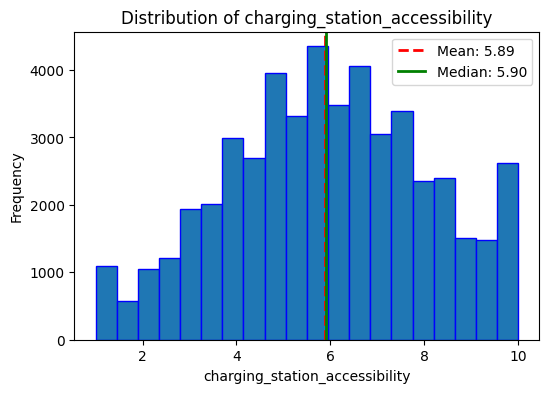


charging_station_accessibility
Mean   : 5.89
Median : 5.90


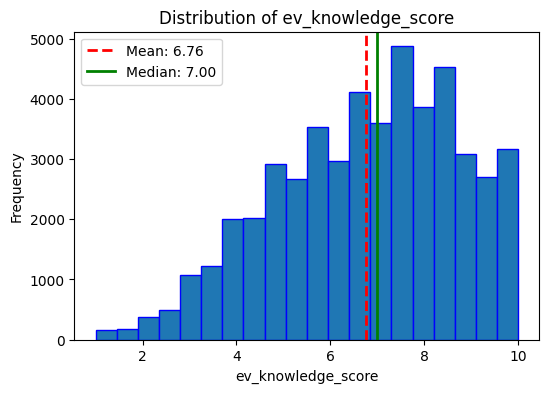


ev_knowledge_score
Mean   : 6.76
Median : 7.00


In [100]:
num_cols = ['charging_station_accessibility', 'ev_knowledge_score']

for col in num_cols:

    mean_val = df[col].mean()
    median_val = df[col].median()

    plt.figure(figsize=(6,4))

    plt.hist(df[col], bins=20, edgecolor='blue')

    # Mean Line
    plt.axvline(mean_val,color='red',linestyle='--',linewidth=2,label=f'Mean: {mean_val:.2f}')

    # Median Line
    plt.axvline(median_val,color='green',linestyle='-',linewidth=2,label=f'Median: {median_val:.2f}')

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

    print(f"\n{col}")
    print(f"Mean   : {mean_val:.2f}")
    print(f"Median : {median_val:.2f}")

The mean and median values for charging_station_accessibility and ev_knowledge_score were very close, indicating minimal skewness and a relatively balanced distribution. Therefore, median imputation was used to handle missing values, as it provides a robust measure of central tendency and is less affected by potential outliers.

In [101]:
#charging_station_accessibility, replace missing values with the Median.

df['charging_station_accessibility'].fillna(
    df['charging_station_accessibility'].median(),
    inplace=True
)

/tmp/ipykernel_5691/1479900472.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['charging_station_accessibility'].fillna(


In [102]:
# ev_knowledge_score,Replace missing values with the Median.

df['ev_knowledge_score'].fillna(
    df['ev_knowledge_score'].median(),
    inplace=True
)

/tmp/ipykernel_5691/195258194.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ev_knowledge_score'].fillna(


In [103]:
# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
age                               0
annual_income                     0
education_level                   0
city_type                         0
daily_commute_km                  0
weekly_travel_distance_km         0
current_vehicle_type              0
vehicle_age_years                 0
fuel_expense_per_month            0
charging_station_accessibility    0
nearest_charging_station_km       0
home_charging_available           0
electricity_cost_per_kwh          0
environmental_awareness_score     0
government_incentive_awareness    0
technology_affinity_score         0
range_anxiety_score               0
battery_replacement_concern       0
ev_knowledge_score                0
previous_ev_experience            0
ev_adoption_likelihood            0
monthly_energy_consumption_kwh    0
monthly_charging_cost             0
dtype: int64


In [104]:
# Convert binary values (1/0) into meaningful categorical labels (Yes/No)
df['home_charging_available'] = df['home_charging_available'].map({
    1: 'Yes',
    0: 'No'
})

In [105]:
# Convert binary values (1/0) into descriptive categories (Yes/No)
df['previous_ev_experience'] = df['previous_ev_experience'].map({
    1: 'Yes',
    0: 'No'
})

In [106]:
#data types check
data_types = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values
})

data_types

,Column,Data Type
0,age,int64
1,annual_income,float64
2,education_level,object
3,city_type,object
4,daily_commute_km,float64
5,weekly_travel_distance_km,float64
6,current_vehicle_type,object
7,vehicle_age_years,float64
8,fuel_expense_per_month,float64
9,charging_station_accessibility,float64


**Outlier Analysis and cleaning**

In [107]:
#Identify Numerical Columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(num_cols)

Index(['age', 'annual_income', 'daily_commute_km', 'weekly_travel_distance_km',
       'vehicle_age_years', 'fuel_expense_per_month',
       'charging_station_accessibility', 'nearest_charging_station_km',
       'electricity_cost_per_kwh', 'environmental_awareness_score',
       'government_incentive_awareness', 'technology_affinity_score',
       'range_anxiety_score', 'battery_replacement_concern',
       'ev_knowledge_score', 'monthly_energy_consumption_kwh',
       'monthly_charging_cost'],
      dtype='object')


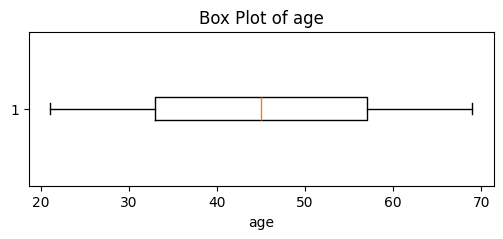

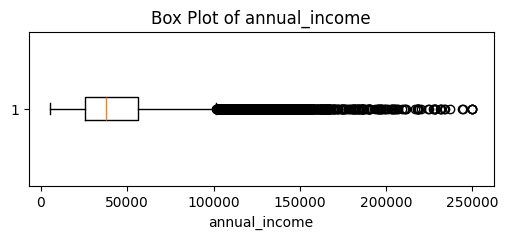

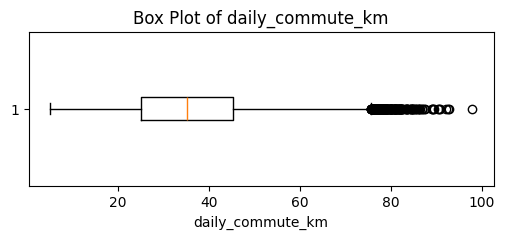

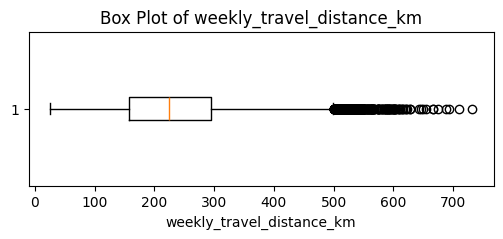

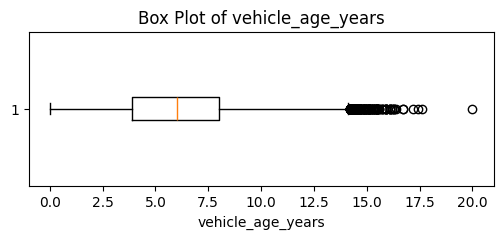

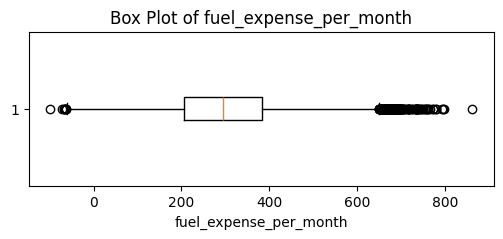

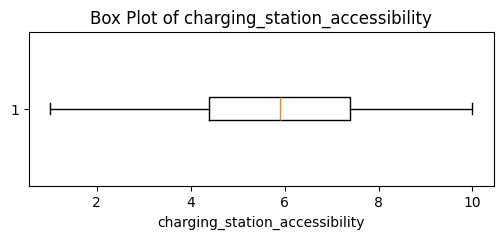

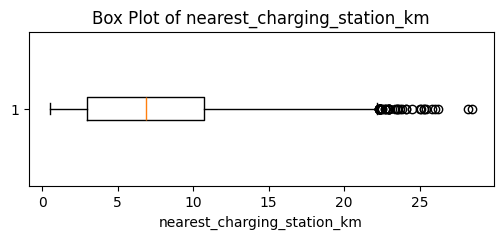

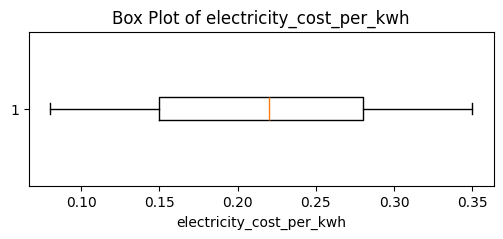

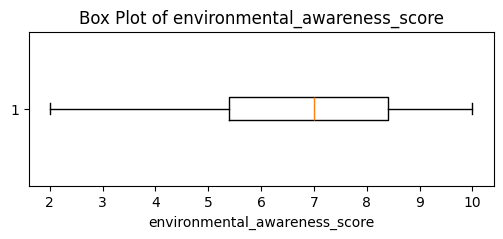

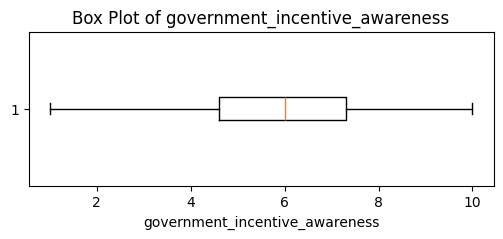

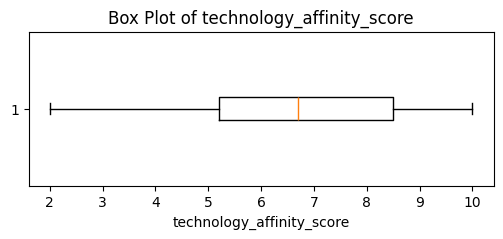

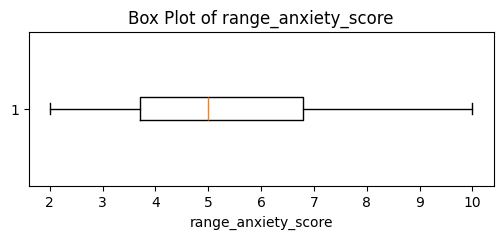

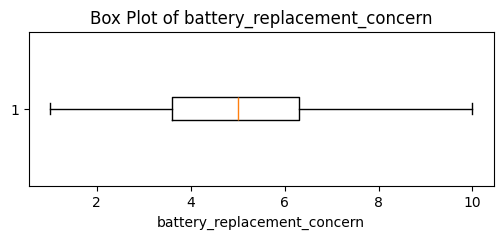

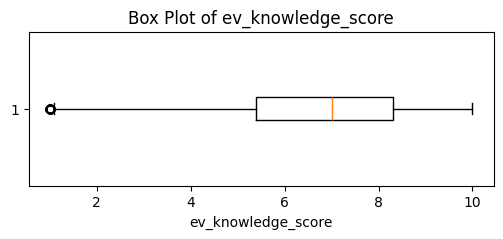

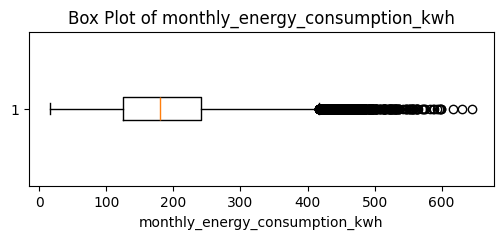

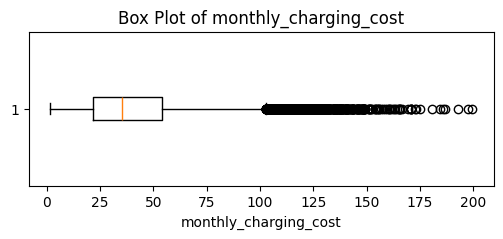

In [108]:
for col in num_cols:
    plt.figure(figsize=(6,2))
    plt.boxplot(df[col], vert=False)
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)
    plt.show()

In [109]:
#Percentage of Outliers before capping
outlier_summary = []

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_percentage = (len(outliers) / len(df)) * 100

    outlier_summary.append({
        'Column': col,
        'Outlier Percentage': round(outlier_percentage, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df.sort_values(
    by='Outlier Percentage',
    ascending=False
)

,Column,Outlier Percentage
1,annual_income,3.76
16,monthly_charging_cost,2.25
15,monthly_energy_consumption_kwh,1.29
3,weekly_travel_distance_km,0.75
2,daily_commute_km,0.38
5,fuel_expense_per_month,0.36
4,vehicle_age_years,0.34
14,ev_knowledge_score,0.13
7,nearest_charging_station_km,0.08
0,age,0.00


In [110]:
# Select Numerical Columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Capping Outliers
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    df[col] = df[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print("Outlier capping completed successfully.")

Outlier capping completed successfully.


In [111]:
#Percentage of Outliers after capping
outlier_summary = []

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_percentage = (len(outliers) / len(df)) * 100

    outlier_summary.append({
        'Column': col,
        'Outlier Percentage': round(outlier_percentage, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df.sort_values(
    by='Outlier Percentage',
    ascending=False
)

,Column,Outlier Percentage
0,age,0.0
1,annual_income,0.0
2,daily_commute_km,0.0
3,weekly_travel_distance_km,0.0
4,vehicle_age_years,0.0
5,fuel_expense_per_month,0.0
6,charging_station_accessibility,0.0
7,nearest_charging_station_km,0.0
8,electricity_cost_per_kwh,0.0
9,environmental_awareness_score,0.0


Outlier analysis revealed the presence of extreme values in variables such as annual_income, monthly_charging_cost, and monthly_energy_consumption_kwh. To reduce the influence of these extreme observations on statistical analysis and machine learning models while preserving all records, the IQR-based capping method was applied.

# **Exploratory Data Analysis (EDA)**

# **Univariate Analysis**

**Target variable**

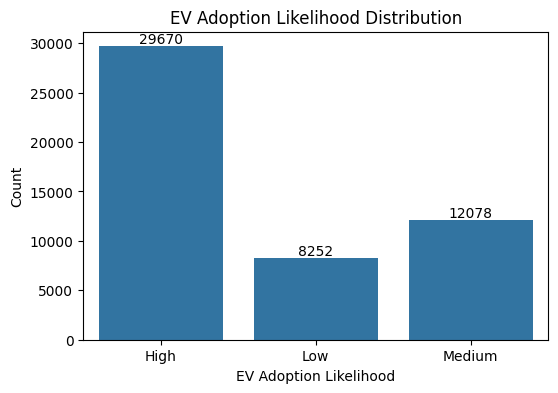

In [112]:
#TARGET VARIABLE ANALYSIS
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x='ev_adoption_likelihood')

plt.title('EV Adoption Likelihood Distribution')
plt.xlabel('EV Adoption Likelihood')
plt.ylabel('Count')

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

**ev_adoption_likelihood**

The majority of customers (59.34%) fall into the High EV Adoption Likelihood category, indicating a strong potential market for electric vehicles.

Around 24.16% of customers exhibit a Medium likelihood of adopting EVs, suggesting that targeted awareness campaigns, incentives, and infrastructure improvements could further encourage adoption.

Only 16.50% of customers are classified as having a Low likelihood of adopting EVs, indicating that a relatively small segment remains resistant to EV adoption.

**Demographic Features analysis**

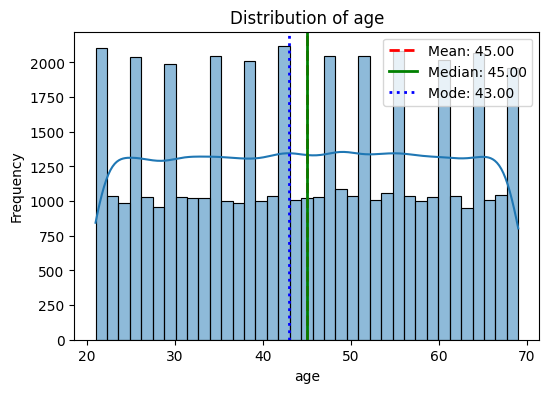


age
Mean   : 45.00
Median : 45.00
Mode   : 43.00


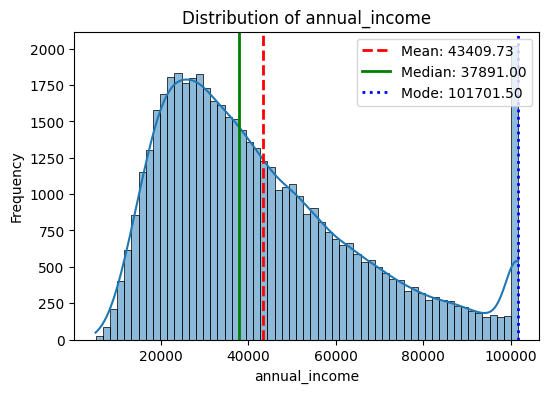


annual_income
Mean   : 43409.73
Median : 37891.00
Mode   : 101701.50


In [113]:
# Numerical Demographic Features
num_demo = ['age', 'annual_income']

for col in num_demo:

    mean_val = df[col].mean()
    median_val = df[col].median()
    mode_val = df[col].mode()[0]

    plt.figure(figsize=(6,4))

    sns.histplot(df[col], kde=True)

    # Mean Line
    plt.axvline(mean_val, color='red',linestyle='--',linewidth=2,label=f'Mean: {mean_val:.2f}')

    # Median Line
    plt.axvline(median_val,color='green',linestyle='-',linewidth=2,label=f'Median: {median_val:.2f}')

    # Mode Line
    plt.axvline(mode_val,color='blue',linestyle=':',linewidth=2,label=f'Mode: {mode_val:.2f}')

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.legend()

    plt.show()

    print(f"\n{col}")
    print(f"Mean   : {mean_val:.2f}")
    print(f"Median : {median_val:.2f}")
    print(f"Mode   : {mode_val:.2f}")

**Age Distribution**

Mean = 45.00, Median = 45.00, Mode = 43.00 → The distribution is almost perfectly symmetric, showing a balanced age group centered around middle-aged customers.

**Annual Income**

Mean = 43409.73, Median = 37891.00, Mode = 101701.50 → The distribution is right-skewed, indicating most users fall in the middle-income range, but a few high-income values pull the mean upward.



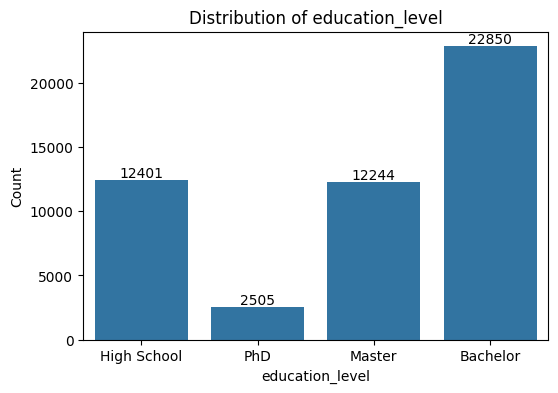

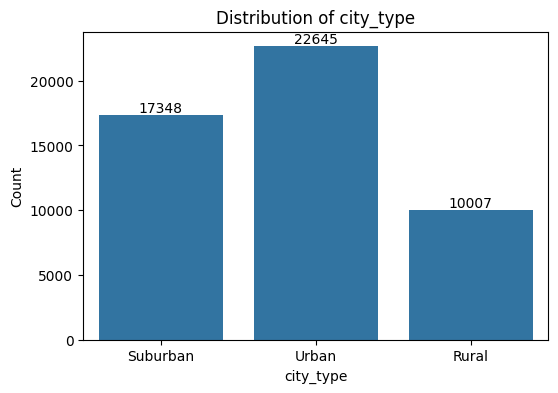

In [114]:
# Categorical Demographic Features
cat_demo = ['education_level', 'city_type']

for col in cat_demo:

    plt.figure(figsize=(6,4))

    ax = sns.countplot(data=df, x=col)

    for container in ax.containers:
        ax.bar_label(container)

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

    plt.show()

**Education Level**

Bachelor (22850), High School (12401), Master (12244), PhD (2505) → The distribution shows that most respondents are Bachelor degree holders, followed by High School and Master, while PhD holders are the smallest group, indicating a moderately educated population with strong representation from mid-level education.

**City Type**

Urban (22645), Suburban (17348), Rural (10007) → The dataset is dominated by Urban respondents, followed by Suburban and then Rural areas, suggesting that EV adoption insights are more influenced by urban and semi-urban populations, where infrastructure and awareness are typically higher.

**Travel & Vehicle Features**

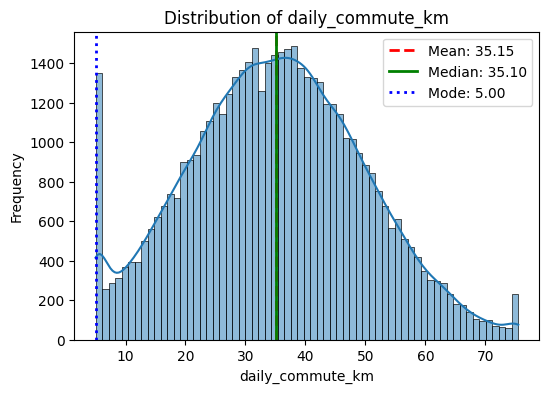


daily_commute_km
Mean   : 35.15
Median : 35.10
Mode   : 5.00


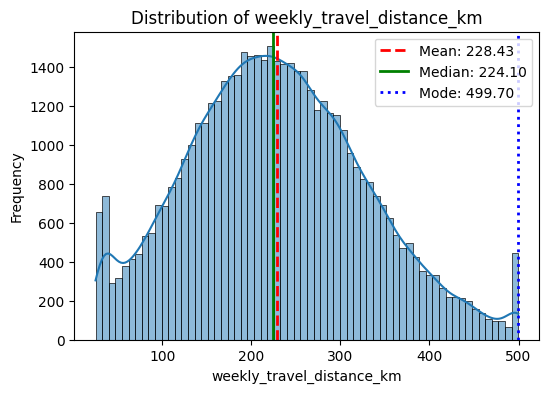


weekly_travel_distance_km
Mean   : 228.43
Median : 224.10
Mode   : 499.70


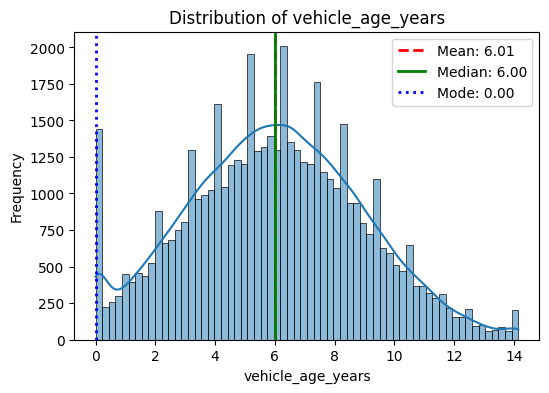


vehicle_age_years
Mean   : 6.01
Median : 6.00
Mode   : 0.00


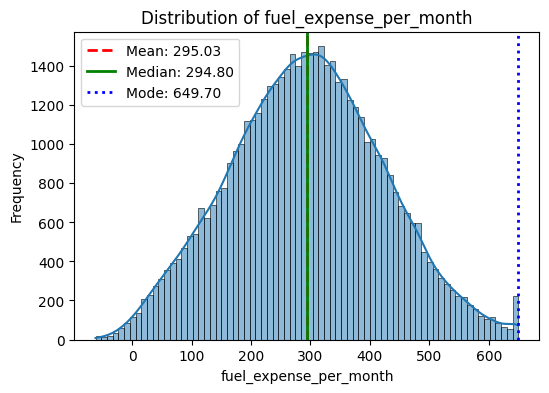


fuel_expense_per_month
Mean   : 295.03
Median : 294.80
Mode   : 649.70


In [115]:
# Numerical Features Travel & Vehicle  Analysis

num_cols = [
    'daily_commute_km',
    'weekly_travel_distance_km',
    'vehicle_age_years',
    'fuel_expense_per_month'
]

for col in num_cols:

    mean_val = df[col].mean()
    median_val = df[col].median()
    mode_val = df[col].mode()[0]

    plt.figure(figsize=(6,4))

    sns.histplot(df[col], kde=True)

    # Mean line
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2,label=f"Mean: {mean_val:.2f}")

    # Median line
    plt.axvline(median_val, color='green', linestyle='-',linewidth=2, label=f"Median: {median_val:.2f}")

    # Mode line
    plt.axvline(mode_val, color='blue', linestyle=':',linewidth=2, label=f"Mode: {mode_val:.2f}")

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.legend()

    plt.show()

    print(f"\n{col}")
    print(f"Mean   : {mean_val:.2f}")
    print(f"Median : {median_val:.2f}")
    print(f"Mode   : {mode_val:.2f}")

**Daily Commute Distance**

Mean = 35.15, Median = 35.10, Mode = 5.00 → The distribution is mostly symmetrical around 35 km, but the low mode suggests a small group of users with very short commutes, creating slight variation in commuting behavior.

**Weekly Travel Distance**

Mean = 228.43, Median = 224.10, Mode = 499.70 → The distribution is slightly right-skewed, indicating most users travel moderate distances weekly, while a smaller group travels very high distances.

**Vehicle Age**

Mean = 6.01, Median = 6.00, Mode = 0.00 → The distribution is mostly centered around 6 years, but the mode at 0 indicates a significant number of very new vehicles, suggesting a mixed ownership profile.

**Fuel Expense Per Month**

Mean = 295.03, Median = 294.80, Mode = 649.70 → The distribution is slightly right-skewed, showing most users have moderate fuel expenses, while a smaller group incurs very high fuel costs, which may influence EV adoption interest.

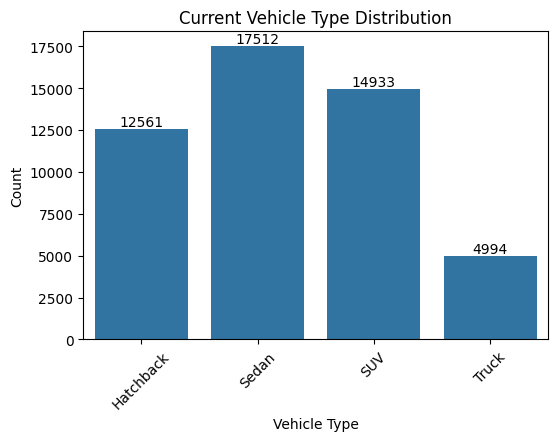

In [116]:
# Categorical  Features Travel & Vehicle  Analysis
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x='current_vehicle_type')

for container in ax.containers:
    ax.bar_label(container)

plt.title('Current Vehicle Type Distribution')
plt.xlabel('Vehicle Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.show()

**Current Vehicle Type**

Sedan (17512), SUV (14933), Hatchback (12561), Truck (4994) → The distribution shows that Sedans are the most commonly used vehicles, followed closely by SUVs and Hatchbacks, while Trucks form the smallest group. This indicates that the dataset is dominated by personal passenger vehicles, which are more likely to be considered for EV replacement compared to commercial vehicles like trucks.

**Charging Infrastructure Features Analysis**

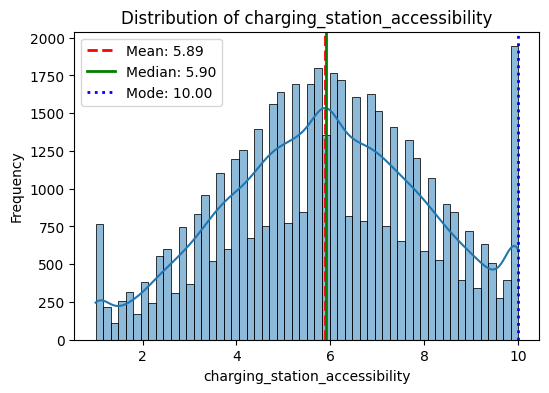


charging_station_accessibility
Mean   : 5.89
Median : 5.90
Mode   : 10.00


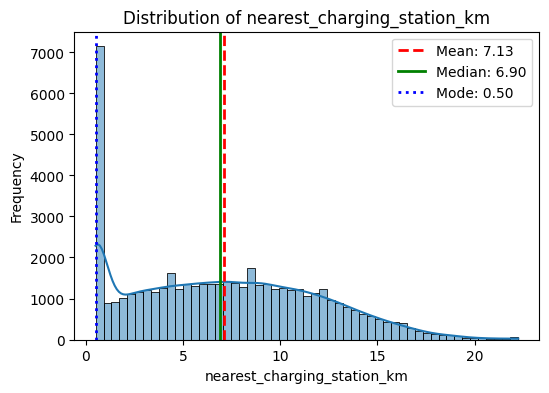


nearest_charging_station_km
Mean   : 7.13
Median : 6.90
Mode   : 0.50


In [117]:
# Numerical Charging Infrastructure Features
charging_num = [
    'charging_station_accessibility',
    'nearest_charging_station_km'
]

for col in charging_num:

    mean_val = df[col].mean()
    median_val = df[col].median()
    mode_val = df[col].mode()[0]

    plt.figure(figsize=(6,4))

    sns.histplot(df[col], kde=True)

    # Mean line
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2,label=f"Mean: {mean_val:.2f}")

    # Median line
    plt.axvline(median_val, color='green', linestyle='-',linewidth=2, label=f"Median: {median_val:.2f}")

    # Mode line
    plt.axvline(mode_val, color='blue', linestyle=':',linewidth=2, label=f"Mode: {mode_val:.2f}")

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.legend()

    plt.show()

    print(f"\n{col}")
    print(f"Mean   : {mean_val:.2f}")
    print(f"Median : {median_val:.2f}")
    print(f"Mode   : {mode_val:.2f}")

**Charging Station Accessibility**

Mean = 5.89, Median = 5.90, Mode = 10.00 → The distribution is almost perfectly symmetric around 5.9, indicating a balanced perception of charging accessibility, while the mode at 10 suggests a smaller group experiencing very high accessibility.

**Nearest Charging Station Distance**

Mean = 7.13, Median = 6.90, Mode = 0.50 → The distribution is slightly right-skewed, meaning most users have nearby charging stations around 7 km, but a few extreme values increase the average, while the mode indicates a subset of users living very close to charging points.

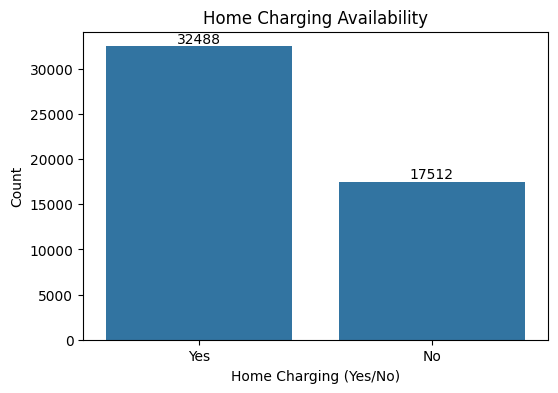

In [118]:
# Categorical Feature: Home Charging Availability

plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x='home_charging_available')

for container in ax.containers:
    ax.bar_label(container)

plt.title('Home Charging Availability')
plt.xlabel('Home Charging (Yes/No)')
plt.ylabel('Count')

plt.show()

**Home Charging Availability**

Yes (32488), No (17512) → The distribution shows that a majority of users have home charging access, indicating strong infrastructure support for EV adoption. However, a significant portion still lacks home charging facilities, which may act as a key barrier and increase reliance on public charging networks, influencing adoption decisions.

**EV Awareness & Behavioral Features analysis**

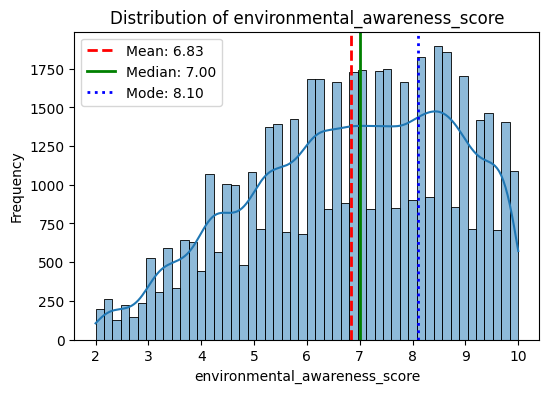


environmental_awareness_score
Mean   : 6.83
Median : 7.00
Mode   : 8.10


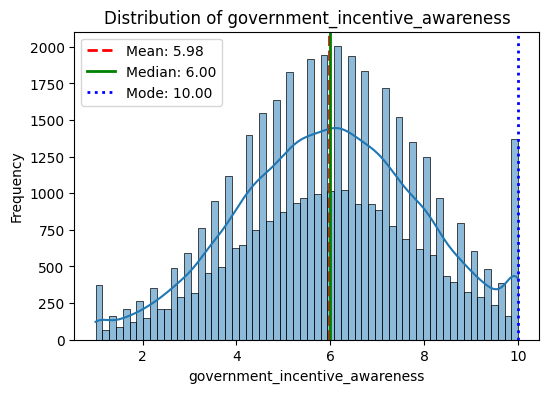


government_incentive_awareness
Mean   : 5.98
Median : 6.00
Mode   : 10.00


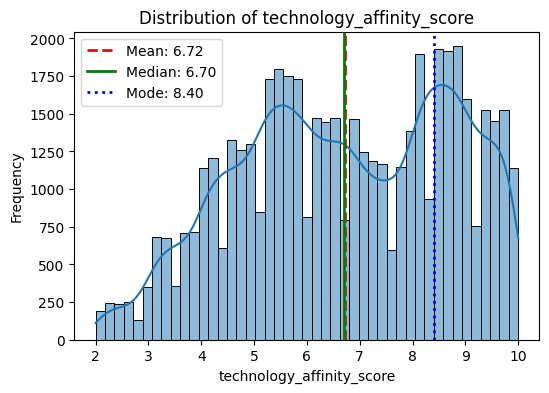


technology_affinity_score
Mean   : 6.72
Median : 6.70
Mode   : 8.40


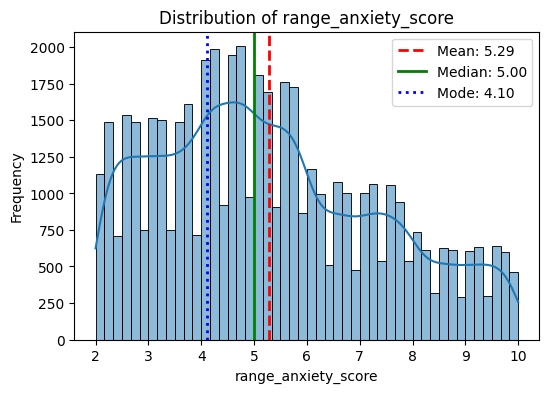


range_anxiety_score
Mean   : 5.29
Median : 5.00
Mode   : 4.10


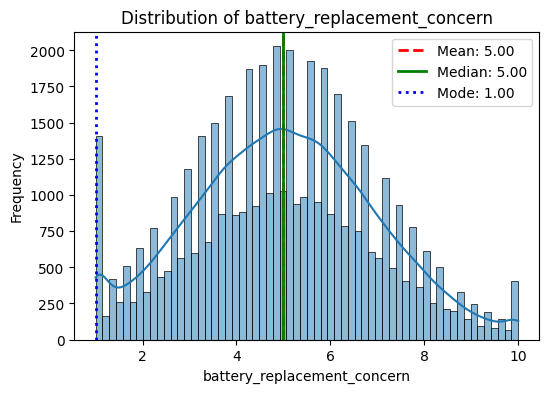


battery_replacement_concern
Mean   : 5.00
Median : 5.00
Mode   : 1.00


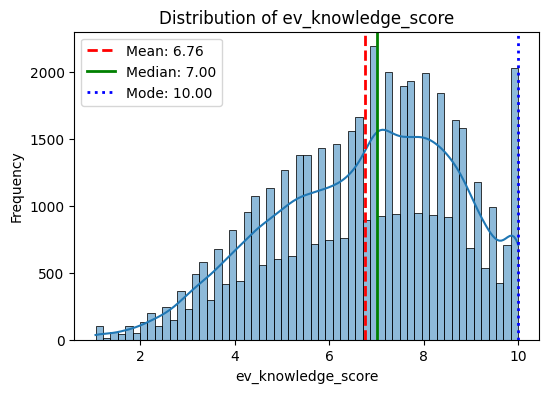


ev_knowledge_score
Mean   : 6.76
Median : 7.00
Mode   : 10.00


In [119]:
ev_num_cols = [
    'environmental_awareness_score',
    'government_incentive_awareness',
    'technology_affinity_score',
    'range_anxiety_score',
    'battery_replacement_concern',
    'ev_knowledge_score'
]

for col in ev_num_cols:

    mean_val = df[col].mean()
    median_val = df[col].median()
    mode_val = df[col].mode()[0]

    plt.figure(figsize=(6,4))

    sns.histplot(df[col], kde=True)

    # Mean
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2,label=f"Mean: {mean_val:.2f}")

    # Median
    plt.axvline(median_val, color='green', linestyle='-',linewidth=2, label=f"Median: {median_val:.2f}")

    # Mode
    plt.axvline(mode_val, color='blue', linestyle=':',linewidth=2, label=f"Mode: {mode_val:.2f}")

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.legend()

    plt.show()

    print(f"\n{col}")
    print(f"Mean   : {mean_val:.2f}")
    print(f"Median : {median_val:.2f}")
    print(f"Mode   : {mode_val:.2f}")

**Environmental Awareness Score**

Mean = 6.83, Median = 7.00, Mode = 8.10 → The distribution is slightly left-skewed and centered around high values, indicating strong environmental consciousness among respondents, which positively supports EV adoption.

**Government Incentive Awareness**

Mean = 5.98, Median = 6.00, Mode = 10.00 → The distribution is fairly balanced with a slight right tail, showing moderate awareness overall, but a smaller group is highly aware of government incentives.

**Technology Affinity Score**

Mean = 6.72, Median = 6.70, Mode = 8.40 → The distribution is almost symmetric and centered at moderately high values, indicating good openness toward new technology among users.

**Range Anxiety Score**

Mean = 5.29, Median = 5.00, Mode = 4.10 → The distribution is slightly right-skewed, suggesting moderate range anxiety levels, with most users experiencing average concern about EV range limitations.

**Battery Replacement Concern**

Mean = 5.00, Median = 5.00, Mode = 1.00 → The distribution is highly varied and right-skewed, indicating that while average concern is moderate, a large group has very low concern about battery replacement.

**EV Knowledge Score**

Mean = 6.76, Median = 7.00, Mode = 10.00 → The distribution is slightly left-skewed, showing generally high EV awareness, with a segment of highly informed users.

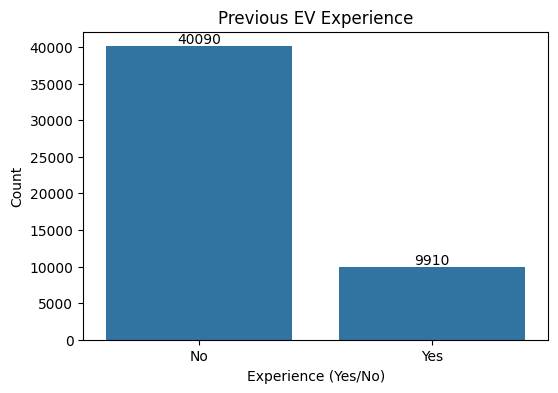

In [120]:
# Previous EV Experience (Categorical)

plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x='previous_ev_experience')

for container in ax.containers:
    ax.bar_label(container)

plt.title('Previous EV Experience')
plt.xlabel('Experience (Yes/No)')
plt.ylabel('Count')

plt.show()

In [121]:
df['previous_ev_experience'].value_counts()

,count
previous_ev_experience,
No,40090
Yes,9910


**Previous EV Experience**

No (40090), Yes (9910) → The distribution shows that a large majority of respondents have no prior EV experience, indicating that EV adoption is still in an early exposure stage for most users. Only a smaller segment has direct experience with EVs, which may influence higher adoption likelihood due to familiarity and reduced uncertainty.

**Energy Consumption Features Analysis**

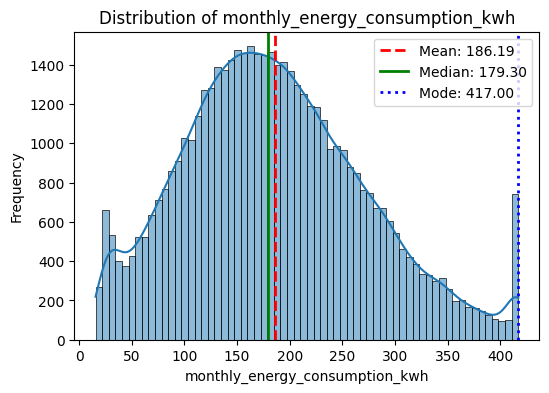


monthly_energy_consumption_kwh
Mean   : 186.19
Median : 179.30
Mode   : 417.00


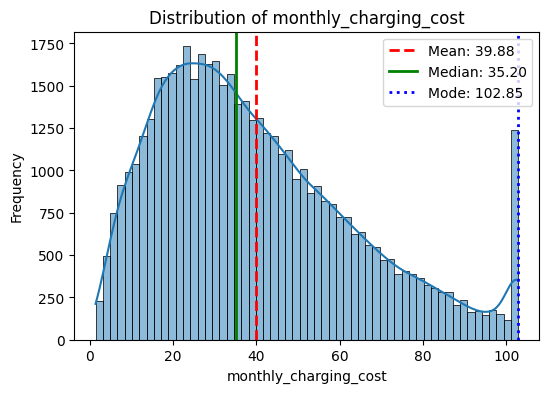


monthly_charging_cost
Mean   : 39.88
Median : 35.20
Mode   : 102.85


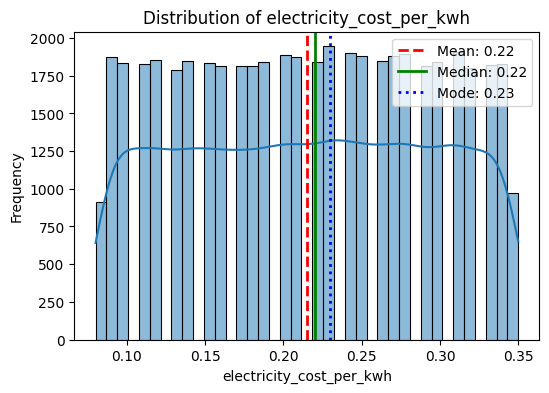


electricity_cost_per_kwh
Mean   : 0.22
Median : 0.22
Mode   : 0.23


In [122]:
energy_cols = [
    'monthly_energy_consumption_kwh',
    'monthly_charging_cost',
    'electricity_cost_per_kwh'
]

for col in energy_cols:

    mean_val = df[col].mean()
    median_val = df[col].median()
    mode_val = df[col].mode()[0]

    plt.figure(figsize=(6,4))

    sns.histplot(df[col], kde=True)

    # Mean line
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2,label=f"Mean: {mean_val:.2f}")

    # Median line
    plt.axvline(median_val, color='green', linestyle='-',linewidth=2, label=f"Median: {median_val:.2f}")

    # Mode line
    plt.axvline(mode_val, color='blue', linestyle=':',linewidth=2, label=f"Mode: {mode_val:.2f}")

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.legend()

    plt.show()

    print(f"\n{col}")
    print(f"Mean   : {mean_val:.2f}")
    print(f"Median : {median_val:.2f}")
    print(f"Mode   : {mode_val:.2f}")

**Monthly Energy Consumption (kWh)**

Mean = 186.19, Median = 179.30, Mode = 417.00 → The distribution is right-skewed, indicating most users have moderate energy consumption, while a smaller group consumes significantly higher energy.

**Monthly Charging Cost**

Mean = 39.88, Median = 35.20, Mode = 102.85 → The distribution is positively skewed, showing that most users incur low-to-moderate charging costs, with a few high-cost users increasing the average.

**Electricity Cost per kWh**

Mean = 0.22, Median = 0.22, Mode = 0.23 → The distribution is almost perfectly symmetric and stable, indicating consistent electricity pricing across the dataset with minimal variation.

# **Feature Selection for Bivariate Analysis and Model Building**

The target variable e_adoption_likelihood is categorical (classification).Feature selection to be  performed using ANOVA F-test for numerical features and Chi-Square test for categorical features with respect to the target variable e_adoption_likelihood.


**ANOVA F-test**

In [123]:
# Encode target variable
le = LabelEncoder()
y = le.fit_transform(df['ev_adoption_likelihood'])

# Select only numerical features
X_num = df.select_dtypes(include=['int64', 'float64'])

# Perform ANOVA F-test
f_scores, p_values = f_classif(X_num, y)

# Create results dataframe
anova_results = pd.DataFrame({
    'Feature': X_num.columns,
    'F_Score': f_scores,
    'P_Value': p_values
}).sort_values(by='P_Value')

anova_results

,Feature,F_Score,P_Value
1,annual_income,4621.057452,0.000000e+00
6,charging_station_accessibility,821.499879,0.000000e+00
11,technology_affinity_score,22547.608677,0.000000e+00
9,environmental_awareness_score,22733.455309,0.000000e+00
12,range_anxiety_score,24694.964710,0.000000e+00
14,ev_knowledge_score,27952.683187,0.000000e+00
13,battery_replacement_concern,573.715353,4.515530e-247
10,government_incentive_awareness,385.146170,1.019955e-166
7,nearest_charging_station_km,303.476180,9.898122e-132
4,vehicle_age_years,1.959942,1.408773e-01


In [124]:
selected_features = anova_results[anova_results['P_Value'] < 0.05]['Feature'].tolist()

print("Selected  Numerical Features:")
print(selected_features)

Selected  Numerical Features:
['annual_income', 'charging_station_accessibility', 'technology_affinity_score', 'environmental_awareness_score', 'range_anxiety_score', 'ev_knowledge_score', 'battery_replacement_concern', 'government_incentive_awareness', 'nearest_charging_station_km']


**Chi-Square test**

In [125]:
# Select categorical features (excluding target)
X_cat = df.select_dtypes(include=['object', 'category']).drop(
    columns=['ev_adoption_likelihood']
)

# Encode categorical features
X_cat_encoded = X_cat.apply(
    lambda col: LabelEncoder().fit_transform(col.astype(str))
)

# Encode target variable
y = LabelEncoder().fit_transform(df['ev_adoption_likelihood'])

# Perform Chi-Square test
chi_scores, p_values = chi2(X_cat_encoded, y)

# Create results dataframe
chi_results = pd.DataFrame({
    'Feature': X_cat.columns,
    'Chi2_Score': chi_scores,
    'P_Value': p_values
}).sort_values(by='P_Value')

chi_results

,Feature,Chi2_Score,P_Value
4,previous_ev_experience,277.294387,6.113486e-61
1,city_type,238.637555,1.515351e-52
3,home_charging_available,158.094840,4.678877e-35
2,current_vehicle_type,3.880840,1.436436e-01
0,education_level,0.476502,7.880049e-01


In [126]:
selected_cat_features = chi_results.loc[
    chi_results['P_Value'] < 0.05, 'Feature'
].tolist()

print("Selected  categorical Features:")
print(selected_cat_features)

Selected  categorical Features:
['previous_ev_experience', 'city_type', 'home_charging_available']


**Selected features based on statistical tests:**

| Feature Type                                              | Selected Features                | Description                                                            |
| --------------------------------------------------------- | -------------------------------- | ---------------------------------------------------------------------- |
| **Numerical Features** (Selected using ANOVA F-test)      | `annual_income`                  | Annual income of the respondent.                                       |
|                                                           | `charging_station_accessibility` | Ease of accessing EV charging stations.                                |
|                                                           | `technology_affinity_score`      | Degree of interest and comfort with new technologies.                  |
|                                                           | `environmental_awareness_score`  | Level of awareness about environmental issues and sustainability.      |
|                                                           | `range_anxiety_score`            | Concern about an EV's driving range before recharging.                 |
|                                                           | `ev_knowledge_score`             | Knowledge and understanding of electric vehicles.                      |
|                                                           | `battery_replacement_concern`    | Concern regarding EV battery replacement costs and lifespan.           |
|                                                           | `government_incentive_awareness` | Awareness of government incentives and subsidies for EV adoption.      |
|                                                           | `nearest_charging_station_km`    | Distance to the nearest EV charging station in kilometers.             |
| **Categorical Features** (Selected using Chi-Square test) | `previous_ev_experience`         | Whether the respondent has prior experience using an electric vehicle. |
|                                                           | `city_type`                      | Type of residential area (Urban, Semi-Urban, or Rural).                |
|                                                           | `home_charging_available`        | Availability of an EV charging facility at home.                       |


# **Bivariate Analysis**

**Numerical Features vs ev_adoption_likelihood**

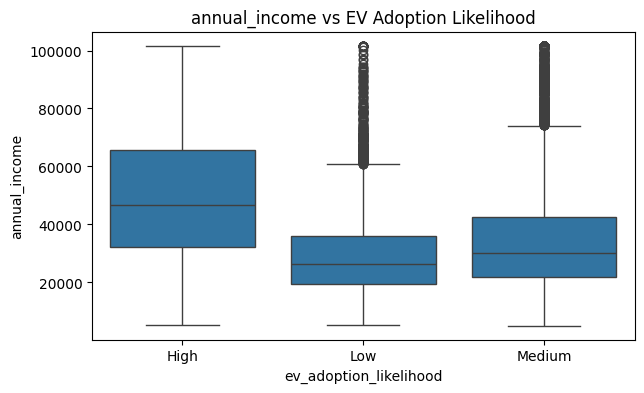

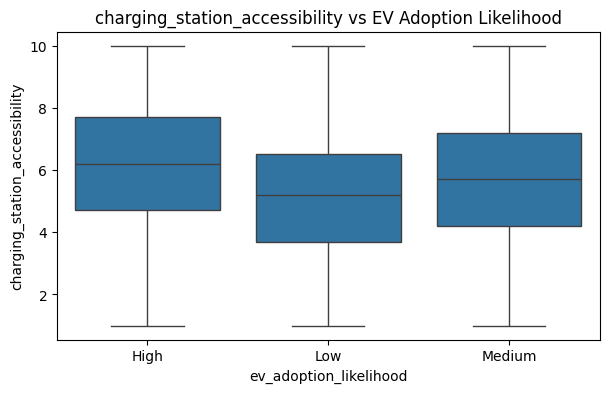

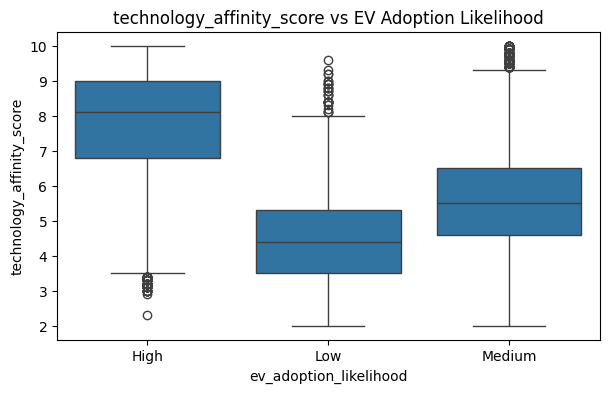

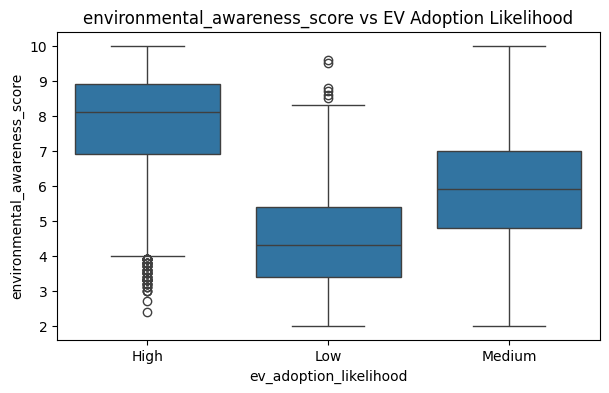

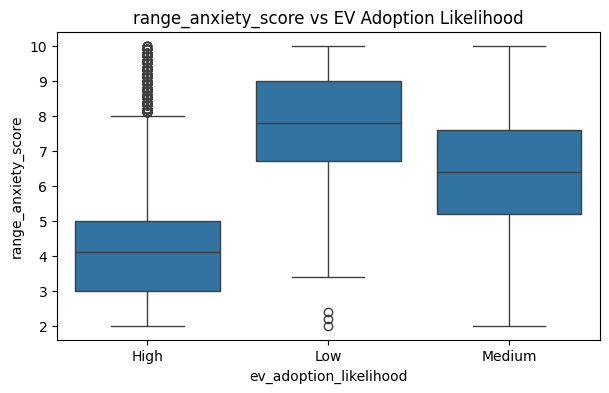

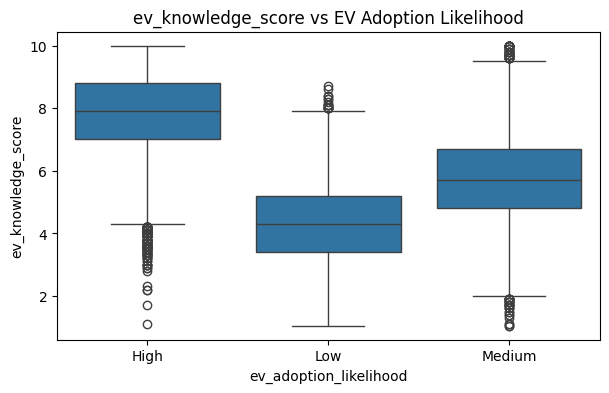

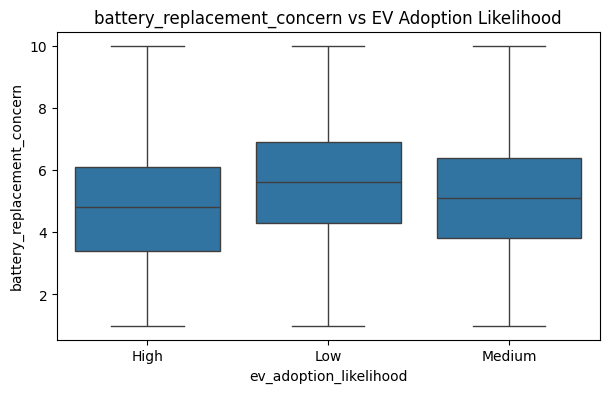

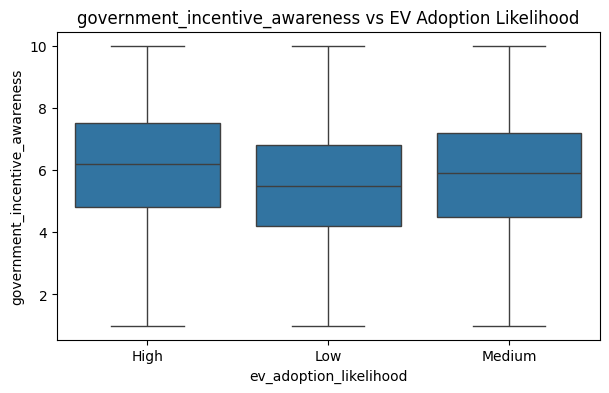

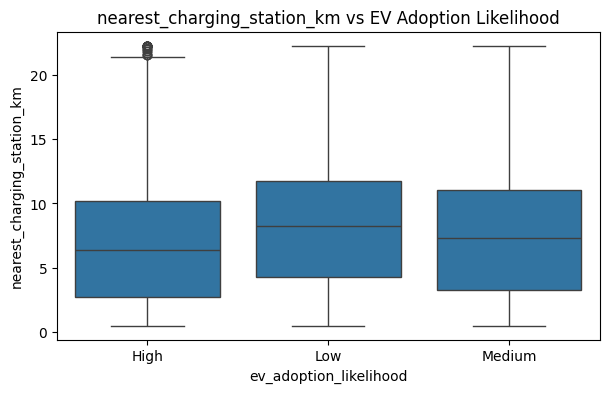

In [127]:
num_features = [
    'annual_income',
    'charging_station_accessibility',
    'technology_affinity_score',
    'environmental_awareness_score',
    'range_anxiety_score',
    'ev_knowledge_score',
    'battery_replacement_concern',
    'government_incentive_awareness',
    'nearest_charging_station_km'
]

for col in num_features:
    plt.figure(figsize=(7,4))
    sns.boxplot(x='ev_adoption_likelihood', y=col, data=df)
    plt.title(f'{col} vs EV Adoption Likelihood')
    plt.show()

**Interpretation of Box Plots (Numerical Features vs ev_adoption_likelihood)**

**annual_income:** The High adoption group has the highest median income, indicating that higher-income individuals are more likely to adopt EVs.

**charging_station_accessibility:** The median accessibility score is highest for the High adoption group, suggesting that better access to charging stations increases EV adoption likelihood.

**technology_affinity_score:** Higher median scores in the High adoption group indicate that individuals who are more comfortable with technology are more likely to adopt EVs.

**environmental_awareness_score:** The High adoption group exhibits higher environmental awareness, suggesting that environmentally conscious individuals are more inclined to adopt EVs.

**range_anxiety_score:** Lower median range anxiety scores in the High adoption group indicate that reduced concerns about driving range encourage EV adoption.

**ev_knowledge_score**: Higher median EV knowledge scores are associated with a greater likelihood of EV adoption, highlighting the importance of awareness and understanding of EV technology.

**battery_replacement_concern:** Lower concern regarding battery replacement costs and lifespan is associated with higher EV adoption likelihood.

**government_incentive_awareness:** The High adoption group has the highest awareness of government incentives, indicating that incentives and subsidies positively influence EV adoption.

**nearest_charging_station_km:** The High adoption group has the shortest median distance to charging stations, suggesting that proximity to charging infrastructure encourages EV adoption.

**Outliers:** A few outliers are present across some features, indicating the existence of extreme but potentially valid observations in the dataset.

**categorical features vs ev_adoption_likelihood**

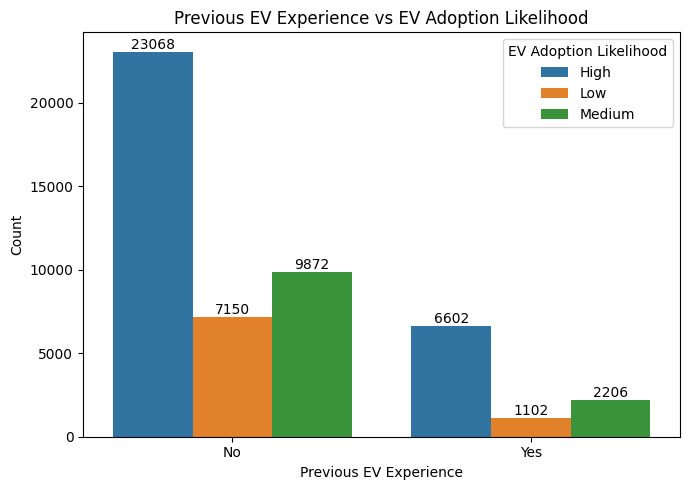

In [128]:
#previous_ev_experience vs ev_adoption_likelihood
# Create count plot
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    x='previous_ev_experience',
    hue='ev_adoption_likelihood',
    data=df
)

# Add count labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

# Add title and labels
plt.title('Previous EV Experience vs EV Adoption Likelihood')
plt.xlabel('Previous EV Experience')
plt.ylabel('Count')
plt.legend(title='EV Adoption Likelihood')

plt.tight_layout()
plt.show()

**previous_ev_experience vs ev_adoption_likelihood**

The High adoption likelihood category has the highest number of respondents in both groups (with and without previous EV experience).
Respondents with previous EV experience show a stronger inclination toward EV adoption, as the majority belong to the High adoption category.

The number of respondents in the Low adoption category is relatively smaller among individuals with prior EV experience.

Prior exposure to electric vehicles appears to positively influence consumers' willingness to adopt EVs.

Overall, the findings suggest that previous EV experience is an important factor influencing EV adoption likelihood.

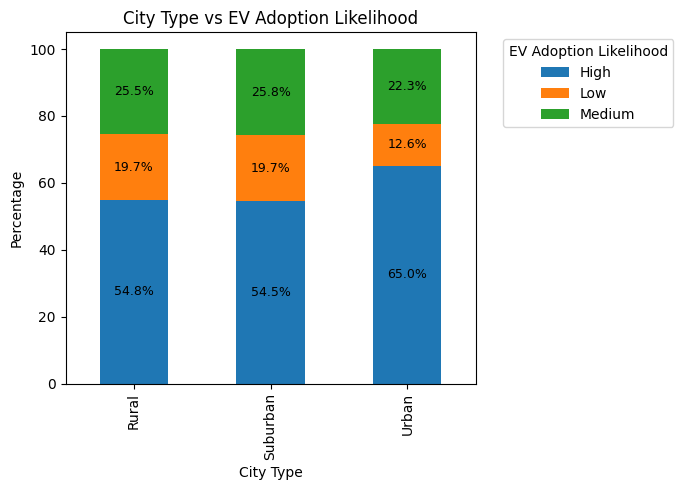

In [129]:
#city_type vs ev_adoption_likelihood
# Create percentage crosstab
ct = pd.crosstab(df['city_type'],df['ev_adoption_likelihood'],normalize='index') * 100

# Plot stacked bar chart
ax = ct.plot(kind='bar',stacked=True,figsize=(7, 5))

# Add percentage labels
for container in ax.containers:
    labels = [
        f'{v:.1f}%' if v > 0 else ''
        for v in container.datavalues
    ]
    ax.bar_label(container,labels=labels,label_type='center',fontsize=9)

# Add title and labels
plt.title('City Type vs EV Adoption Likelihood')
plt.xlabel('City Type')
plt.ylabel('Percentage')

# Move legend outside the plot
plt.legend(title='EV Adoption Likelihood',bbox_to_anchor=(1.05, 1),loc='upper left')
plt.tight_layout()
plt.show()

**city_type vs ev_adoption_likelihood**

Urban respondents have the highest proportion of High EV adoption likelihood (65.02%) compared to Suburban (54.54%) and Rural (54.81%) respondents.

The proportion of respondents with Low EV adoption likelihood is lowest in Urban areas (12.65%), whereas Rural and Suburban areas have similar and higher proportions (approximately 19.70%).

Urban residents also have a lower proportion of Medium adoption likelihood (22.34%) compared to Rural (25.49%) and Suburban (25.76%) respondents.

The findings suggest that individuals living in Urban areas are more likely to adopt electric vehicles, possibly due to better infrastructure, greater awareness, and easier access to charging facilities.

In contrast, respondents from Rural and Suburban areas exhibit comparatively lower adoption likelihood, indicating potential barriers such as limited charging infrastructure and lower exposure to EV technologies.

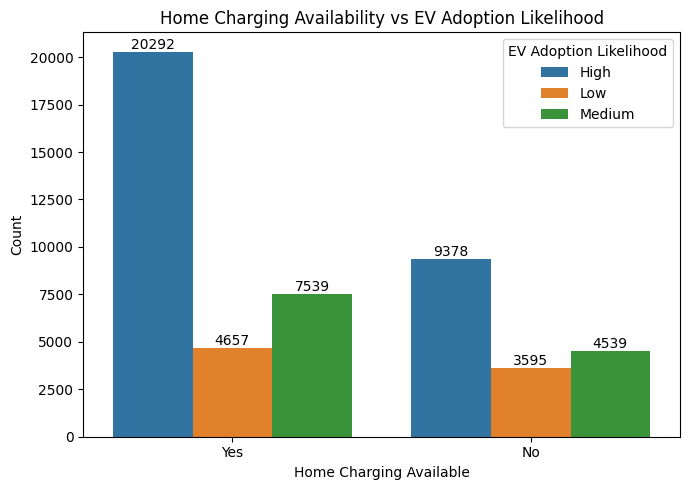

In [130]:
# home_charging_available vs ev_adoption_likelihood
# Create count plot
plt.figure(figsize=(7, 5))

ax = sns.countplot(x='home_charging_available',hue='ev_adoption_likelihood',data=df)

# Add count labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

# Add title and labels
plt.title('Home Charging Availability vs EV Adoption Likelihood')
plt.xlabel('Home Charging Available')
plt.ylabel('Count')
plt.legend(title='EV Adoption Likelihood')

plt.tight_layout()
plt.show()

**home_charging_available vs ev_adoption_likelihood**

The High adoption likelihood category has the highest number of respondents for both groups, with and without home charging availability.

Respondents with home charging facilities have a substantially higher number of individuals in the High adoption category (20,292) compared to those without home charging (9,378).

The number of respondents in the Low adoption category is relatively lower among individuals with home charging availability.

The availability of a home charging facility appears to positively influence consumers' willingness to adopt electric vehicles.

Easy and convenient access to charging at home reduces charging-related concerns and increases the likelihood of EV adoption.

# **Multivariate Analysis**

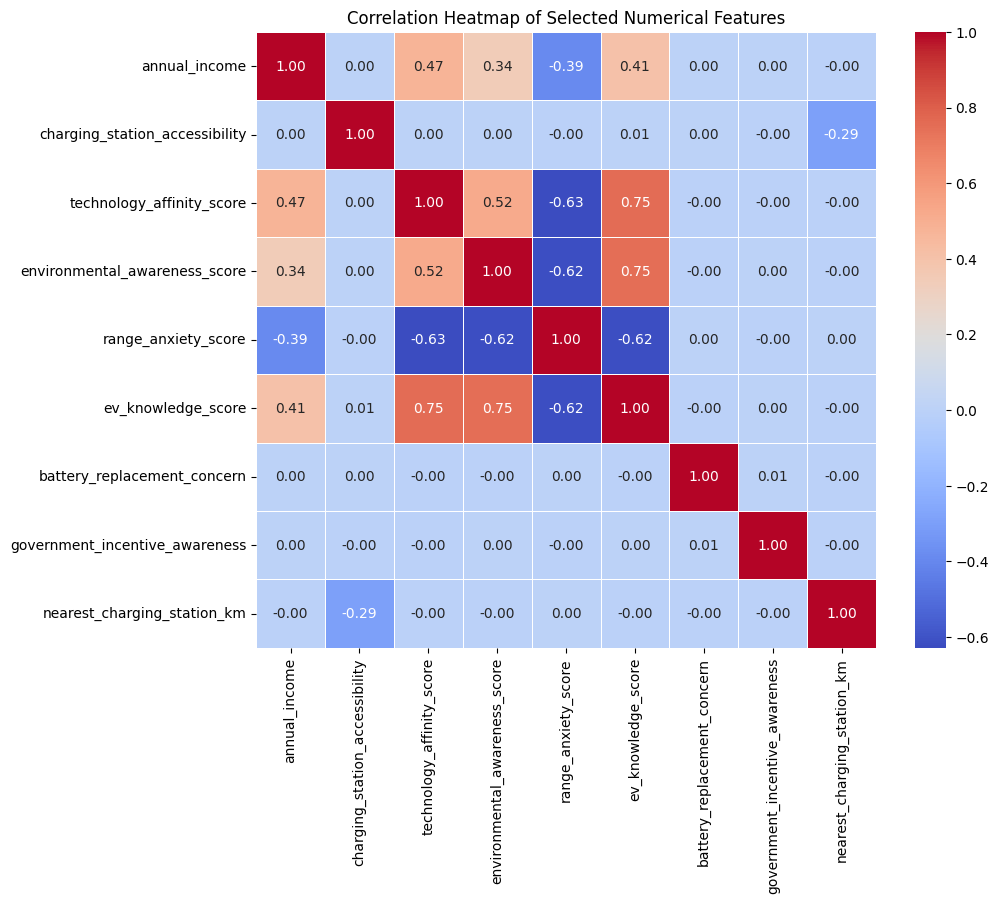

In [131]:
# Selected numerical features
num_features = [
    'annual_income',
    'charging_station_accessibility',
    'technology_affinity_score',
    'environmental_awareness_score',
    'range_anxiety_score',
    'ev_knowledge_score',
    'battery_replacement_concern',
    'government_incentive_awareness',
    'nearest_charging_station_km'
]

# Compute correlation matrix
corr = df[num_features].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Selected Numerical Features')
plt.show()


The multivariate analysis reveals that technology_affinity_score, environmental_awareness_score, and ev_knowledge_score are strongly and positively related, indicating that respondents who are technologically inclined and environmentally conscious tend to possess greater knowledge about electric vehicles.

These variables also exhibit strong negative correlations with range_anxiety_score, suggesting that increased awareness and knowledge reduce concerns regarding EV driving range. Furthermore, none of the correlation coefficients exceed the threshold of 0.80, indicating the absence of severe multicollinearity among the selected numerical features.

Therefore, all selected variables were retained for subsequent model development.

# **Data Preprocessing**

**Features**

In [132]:
numerical_features = [
    'annual_income',
    'charging_station_accessibility',
    'technology_affinity_score',
    'environmental_awareness_score',
    'range_anxiety_score',
    'ev_knowledge_score',
    'battery_replacement_concern',
    'government_incentive_awareness',
    'nearest_charging_station_km'
]

categorical_features = [
    'previous_ev_experience',
    'city_type',
    'home_charging_available'
]


**Preprocessing Pipeline**

In [133]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)



**Train-Test Split**

In [134]:
X = df[numerical_features + categorical_features]
le = LabelEncoder()
y = le.fit_transform(df['ev_adoption_likelihood'])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# **Logistic Regression**

In [135]:
# Logistic Regression Pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        multi_class='multinomial',
        max_iter=1000,
        random_state=42
    ))
])

# Train Model
lr_pipeline.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_pipeline.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr, average='weighted')
recall = recall_score(y_test, y_pred_lr, average='weighted')
f1 = f1_score(y_test, y_pred_lr, average='weighted')

# Print Metrics

print("-----------------------------------LOGISTIC REGRESSION RESULTS---------------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


-----------------------------------LOGISTIC REGRESSION RESULTS---------------------------------
Accuracy  : 0.8795
Precision : 0.8784
Recall    : 0.8795
F1 Score  : 0.8789

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      5934
           1       0.84      0.83      0.84      1650
           2       0.76      0.74      0.75      2416

    accuracy                           0.88     10000
   macro avg       0.85      0.84      0.84     10000
weighted avg       0.88      0.88      0.88     10000


Confusion Matrix
[[5636    0  298]
 [   1 1369  280]
 [ 366  260 1790]]


**Logistic Regression Model Performance Interpretation**

The Logistic Regression model was developed to predict EV Adoption Likelihood across three categories: Low, Medium, and High. The model achieved an accuracy of 87.95%, indicating that it correctly classified approximately 88 out of every 100 observations. The weighted F1-score of 87.89% further confirms that the model maintains a strong balance between precision and recall across all classes.

# **Random Forest**

In [136]:
# Random Forest Pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

# Train Model
rf_pipeline.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_pipeline.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf, average='weighted')
recall = recall_score(y_test, y_pred_rf, average='weighted')
f1 = f1_score(y_test, y_pred_rf, average='weighted')

# Train/Test Accuracy
train_acc = rf_pipeline.score(X_train, y_train)
test_acc = rf_pipeline.score(X_test, y_test)

# Print Results
print("---------------------------------RANDOM FOREST RESULTS-----------------------------------------")

print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")

print(f"\nAccuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

---------------------------------RANDOM FOREST RESULTS-----------------------------------------
Train Accuracy : 1.0000
Test Accuracy  : 0.8619

Accuracy  : 0.8619
Precision : 0.8610
Recall    : 0.8619
F1 Score  : 0.8613

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      5934
           1       0.83      0.78      0.81      1650
           2       0.71      0.71      0.71      2416

    accuracy                           0.86     10000
   macro avg       0.83      0.81      0.82     10000
weighted avg       0.86      0.86      0.86     10000


Confusion Matrix
[[5600    0  334]
 [   2 1293  355]
 [ 429  261 1726]]


**Random Forest Model Performance Interpretation**

The Random Forest model achieved an accuracy of 86.19% and an F1-score of 86.13%, demonstrating strong predictive performance for EV adoption likelihood classification. The model performed best for the High adoption category but showed lower effectiveness in classifying Medium adoption likelihood respondents. A significant gap between training accuracy (100%) and testing accuracy (86.19%) indicates overfitting, suggesting limited generalization to unseen data. Compared to Logistic Regression (87.95% accuracy), Random Forest produced slightly lower performance across all evaluation metrics. Therefore, Logistic Regression was identified as the more suitable model for this dataset

# **XGBoost**

In [137]:
# Encode target variable
le = LabelEncoder()
y = le.fit_transform(df['ev_adoption_likelihood'])

# XGBoost Pipeline
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        eval_metric='mlogloss',
        random_state=42
    ))
])

# Train Model
xgb_pipeline.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_pipeline.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb, average='weighted')
recall = recall_score(y_test, y_pred_xgb, average='weighted')
f1 = f1_score(y_test, y_pred_xgb, average='weighted')

print("-----------------------------------XGBOOST RESULTS---------------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_xgb))

-----------------------------------XGBOOST RESULTS---------------------------------
Accuracy  : 0.8676
Precision : 0.8671
Recall    : 0.8676
F1 Score  : 0.8673

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      5934
           1       0.83      0.81      0.82      1650
           2       0.73      0.73      0.73      2416

    accuracy                           0.87     10000
   macro avg       0.83      0.82      0.83     10000
weighted avg       0.87      0.87      0.87     10000


Confusion Matrix
[[5592    1  341]
 [   2 1332  316]
 [ 383  281 1752]]


**XGBoost Model Performance Interpretation**

The XGBoost model achieved an accuracy of 86.76% and an F1-score of 86.73%, indicating strong performance in classifying EV adoption likelihood. The model demonstrated excellent prediction capability for the High adoption category, while performance for the Medium adoption category was comparatively lower, reflecting the difficulty of distinguishing respondents with moderate adoption likelihood. Compared to Random Forest, XGBoost showed a slight improvement across all evaluation metrics, suggesting better handling of complex feature relationships. However, when compared with Logistic Regression (87.95% accuracy and 87.89% F1-score), XGBoost achieved lower overall performance and classified fewer Medium-category instances correctly.

# **Model Comparision**

In [138]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr, average='weighted'),
        precision_score(y_test, y_pred_rf, average='weighted'),
        precision_score(y_test, y_pred_xgb, average='weighted')
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr, average='weighted'),
        recall_score(y_test, y_pred_rf, average='weighted'),
        recall_score(y_test, y_pred_xgb, average='weighted')
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted'),
        f1_score(y_test, y_pred_xgb, average='weighted')
    ]
})

comparison = comparison.sort_values(by='F1 Score', ascending=False)

print("\n================ MODEL COMPARISON ================\n")
print(comparison.round(4))


================ MODEL COMPARISON ================

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.8795     0.8784  0.8795    0.8789
2              XGBoost    0.8676     0.8671  0.8676    0.8673
1        Random Forest    0.8619     0.8610  0.8619    0.8613


**Model Performance Summary**

The results indicate that Logistic Regression is the most suitable model for predicting EV adoption likelihood in this dataset, outperforming both XGBoost and Random Forest across all evaluation metrics. The relatively small differences between the models suggest that the relationships within the dataset are largely linear and can be effectively captured by a simpler model such as Logistic Regression. Additionally, Logistic Regression offers advantages in terms of interpretability, computational efficiency, and ease of deployment, making it the preferred choice for this classification task.

In [139]:
import joblib

joblib.dump(lr_pipeline, "ev_adoption_model.pkl")

['ev_adoption_model.pkl']

In [143]:
from google.colab import files

files.download('/content/ev_adoption_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>